# Critical batch size

Steps-to-target vs batch size (McCandlish-style). Distinctive for Sven since its update rank is capped at B. Sven vs AdamW on MNIST and nanoGPT.

> Loads the fresh Gram-backend results. Robust to partial data (plots whatever has finished).

In [1]:
import sys, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
sys.path.insert(0, '.')
from style import load_results, average_over_seeds, set_style
from analysis_helpers import (add_derived, best_per_method, seed_mean_best, config_runs, seed_band,
                              errorbar_seeds, fmt_pm, epochs_to_target_table, valid, loss_curve, method_order,
                              n_params_of)
from style import DATASET_TITLES, metric_label
from style import clipped_yerr
from pathlib import Path
set_style()
PLOT_DIR = Path('plots_v2/critbatch'); PLOT_DIR.mkdir(parents=True, exist_ok=True)
from style import method_color
def sven_color(m): return method_color(m)   # global optimizer colours (style.METHOD_COLORS)
def sven_lw(m):    return 2.6 if m=='Sven' else 1.6

In [2]:
SCANS={DATASET_TITLES['mnist_labelreg']:'exp_critbatch_mnist', DATASET_TITLES['nanogpt']:'exp_critbatch_nanogpt'}
data={}
for t,n in SCANS.items():
    try: data[t]=add_derived(load_results(n))
    except FileNotFoundError: print('missing',n)

Loaded 84 runs from ../experiment_results/_cache/exp_critbatch_mnist.slim.pkl (slim cache)
Loaded 84 runs from ../experiment_results/_cache/exp_critbatch_nanogpt.slim.pkl (slim cache)


### Epochs-to-target vs batch size

Target = `MULT` x the best **seed-mean** final val loss of any configuration in that study.
A configuration counts only if **every** seed reaches the target; its score is the seed-mean
number of epochs (error bar = seed spread), and each (optimizer, batch size) point is its best
such configuration. Cells where no configuration qualifies are drawn as hollow "not reached"
markers at the top rather than dropped.

Note: the y-axis is **epochs**, not optimizer steps. A McCandlish-style critical-batch plot wants
steps (= epochs x N/B); see ANALYSIS_FIXES.md, A3.

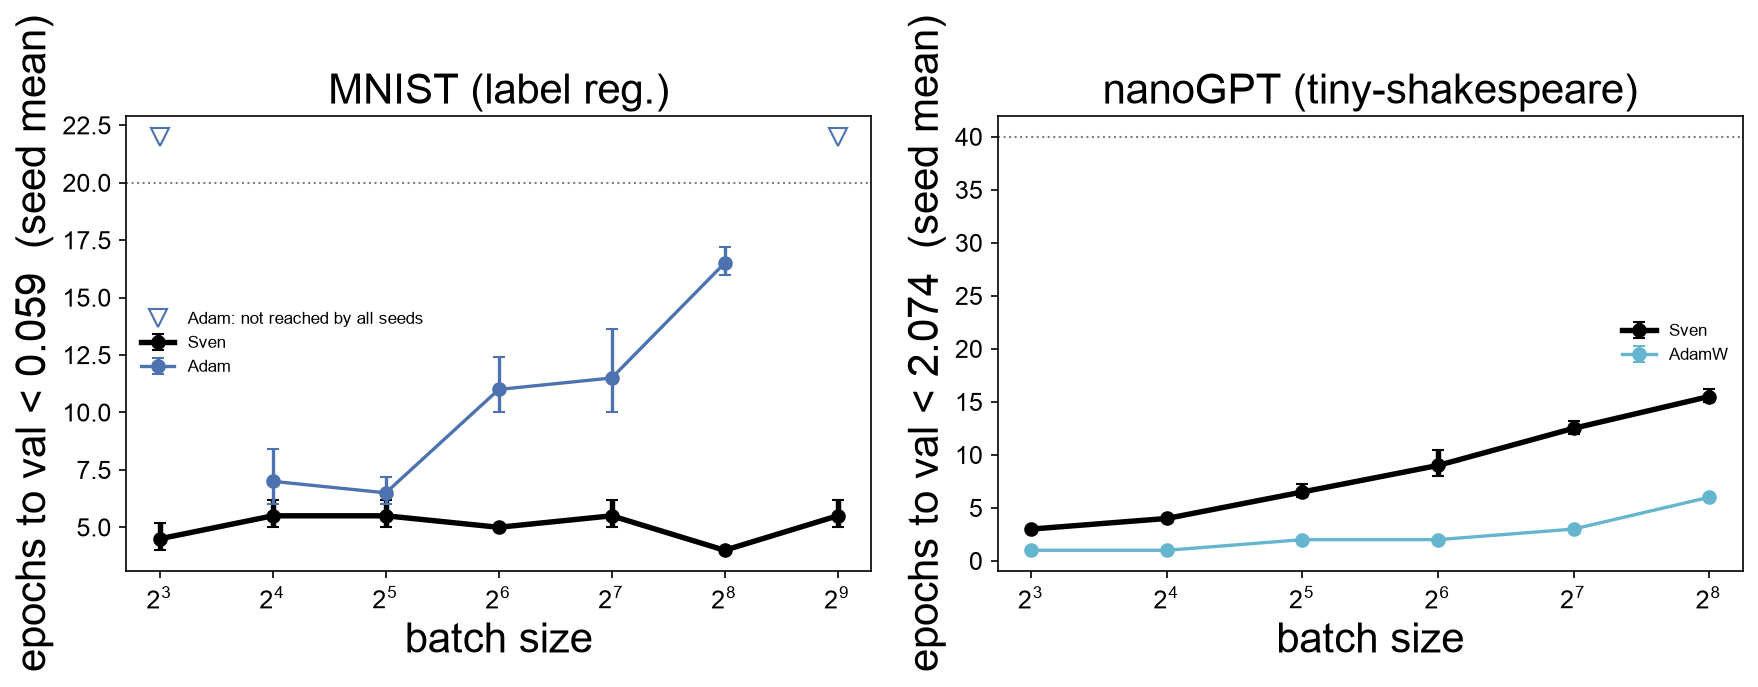

In [3]:
MULT=1.2
fig,axes=plt.subplots(1,len(data),figsize=(6*len(data),4.4),squeeze=False)
for ax,(t,df) in zip(axes[0],data.items()):
    tab,target=epochs_to_target_table(df, mult=MULT)
    n_ep=len(df['losses'].iloc[0]['train']); top=n_ep*1.1
    for m in method_order(tab['method'].unique()):
        s=tab[tab.method==m]
        errorbar_seeds(ax, s[s.reached], 'batch_size', 'e2t', color=sven_color(m), lw=sven_lw(m), label=m)
        miss=s[~s.reached]
        if len(miss):
            ax.plot(miss['batch_size'], [top]*len(miss), 'v', mfc='none', ms=9, color=sven_color(m),
                    label=f'{m}: not reached by all seeds')
    ax.axhline(n_ep, ls=':', c='gray', lw=1)
    ax.set_xscale('log',base=2); ax.set_xlabel('batch size'); ax.set_ylabel(f'epochs to val < {target:.3f}  (seed mean)')
    ax.set_title(t); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(PLOT_DIR/'critical_batch.pdf',bbox_inches='tight'); plt.show()